**Name:** Athena S. Villarin <br>
**Section:** BSCS 3-A AI <br>
**Date:** 04/24/2026 <br>

### Imports

In [1]:
# Standard library
import os
from collections import Counter
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ML / NLP
import torch
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report
from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)

### Dataset

In [2]:
# TASK: Sentiment Classification (Recommended or Not)
# DOMAIN: Steam Game Reviews
# DATASET: ilos-vigil/steam-review-aspect-dataset

dataset = load_dataset("ilos-vigil/steam-review-aspect-dataset")
print(dataset)

DatasetDict({
    train: Dataset({
        features: ['appid', 'review', 'cleaned_review', 'labels'],
        num_rows: 900
    })
    test: Dataset({
        features: ['appid', 'review', 'cleaned_review', 'labels'],
        num_rows: 200
    })
})


### Preprocess & Label

In [3]:
TEXT_COL = "cleaned_review" if "cleaned_review" in dataset["train"].column_names else "review"

def convert_label(example):
    # A review is positive if the majority of its 8 aspect scores are favorable
    aspect_scores = example["labels"]
    example["label"] = 1 if sum(aspect_scores) >= 4 else 0
    return example

dataset_train = dataset["train"].map(convert_label)
dataset_test  = dataset["test"].map(convert_label)

dataset_train = dataset_train.filter(lambda x: x[TEXT_COL] is not None and len(x[TEXT_COL]) > 10)
dataset_test  = dataset_test.filter(lambda x: x[TEXT_COL] is not None and len(x[TEXT_COL]) > 10)

print(f"Using text column : {TEXT_COL}")
print(f"Train distribution: {Counter(dataset_train['label'])}")
print(f"Test distribution : {Counter(dataset_test['label'])}")

Filter:   0%|          | 0/200 [00:00<?, ? examples/s]

Using text column : cleaned_review
Train distribution: Counter({0: 521, 1: 379})
Test distribution : Counter({0: 116, 1: 84})


### Load Model & Tokenize

In [4]:
MODEL_NAME = "distilbert-base-uncased"
NUM_LABELS = 2  # binary: recommended or not

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=NUM_LABELS)

def tokenize(batch):
    return tokenizer(batch[TEXT_COL], padding=True, truncation=True, max_length=128)

train_tokenized = dataset_train.map(tokenize, batched=True)
test_tokenized = dataset_test.map(tokenize, batched=True)

# Force a single binary labels column for sequence classification
if "labels" in train_tokenized.column_names and "label" in train_tokenized.column_names:
    train_tokenized = train_tokenized.remove_columns(["labels"])
if "labels" in test_tokenized.column_names and "label" in test_tokenized.column_names:
    test_tokenized = test_tokenized.remove_columns(["labels"])

if "label" in train_tokenized.column_names:
    train_tokenized = train_tokenized.rename_column("label", "labels")
if "label" in test_tokenized.column_names:
    test_tokenized = test_tokenized.rename_column("label", "labels")

train_tokenized.set_format("torch", columns=["input_ids", "attention_mask", "labels"])
test_tokenized.set_format("torch", columns=["input_ids", "attention_mask", "labels"])

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Map:   0%|          | 0/200 [00:00<?, ? examples/s]

### Fine-Tuning

In [5]:
split = train_tokenized.train_test_split(test_size=0.2, seed=42)
train_ds = split["train"]
eval_ds  = split["test"]

training_args = TrainingArguments(
    output_dir="./steam_game_results",
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    logging_steps=50,
    report_to="none",
    disable_tqdm=True,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=eval_ds,
)

trainer.train()
print("Training complete!")
print(trainer.state.log_history)

c:\Users\ganim\Documents\school\3.2\NLP\Unit 6 act\.venv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


{'eval_loss': '0.6473', 'eval_runtime': '6.925', 'eval_samples_per_second': '25.99', 'eval_steps_per_second': '1.733', 'epoch': '1'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

c:\Users\ganim\Documents\school\3.2\NLP\Unit 6 act\.venv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


{'loss': '0.6475', 'grad_norm': '3.773', 'learning_rate': '3.185e-05', 'epoch': '1.111'}
{'eval_loss': '0.5537', 'eval_runtime': '6.869', 'eval_samples_per_second': '26.21', 'eval_steps_per_second': '1.747', 'epoch': '2'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

c:\Users\ganim\Documents\school\3.2\NLP\Unit 6 act\.venv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


{'loss': '0.5092', 'grad_norm': '7.113', 'learning_rate': '1.333e-05', 'epoch': '2.222'}
{'eval_loss': '0.6306', 'eval_runtime': '6.78', 'eval_samples_per_second': '26.55', 'eval_steps_per_second': '1.77', 'epoch': '3'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'train_runtime': '380.3', 'train_samples_per_second': '5.68', 'train_steps_per_second': '0.355', 'train_loss': '0.5303', 'epoch': '3'}
Training complete!
[{'eval_loss': 0.6473064422607422, 'eval_runtime': 6.9252, 'eval_samples_per_second': 25.992, 'eval_steps_per_second': 1.733, 'epoch': 1.0, 'step': 45}, {'loss': 0.6474711608886718, 'grad_norm': 3.7732760906219482, 'learning_rate': 3.185185185185185e-05, 'epoch': 1.1111111111111112, 'step': 50}, {'eval_loss': 0.5536586046218872, 'eval_runtime': 6.8686, 'eval_samples_per_second': 26.206, 'eval_steps_per_second': 1.747, 'epoch': 2.0, 'step': 90}, {'loss': 0.5092260360717773, 'grad_norm': 7.113217830657959, 'learning_rate': 1.3333333333333333e-05, 'epoch': 2.2222222222222223, 'step': 100}, {'eval_loss': 0.6305949687957764, 'eval_runtime': 6.7799, 'eval_samples_per_second': 26.549, 'eval_steps_per_second': 1.77, 'epoch': 3.0, 'step': 135}, {'train_runtime': 380.2516, 'train_samples_per_second': 5.68, 'train_steps_per_second': 0.355, 'tot

### Evaluation

In [6]:
predictions = trainer.predict(eval_ds)
preds = np.argmax(predictions.predictions, axis=1)
labels = predictions.label_ids

label_names = ["Not Recommended", "Recommended"]
print(classification_report(labels, preds, target_names=label_names))

c:\Users\ganim\Documents\school\3.2\NLP\Unit 6 act\.venv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


                 precision    recall  f1-score   support

Not Recommended       0.81      0.72      0.76       115
    Recommended       0.58      0.69      0.63        65

       accuracy                           0.71       180
      macro avg       0.70      0.71      0.70       180
   weighted avg       0.73      0.71      0.72       180



### PCA Visualization

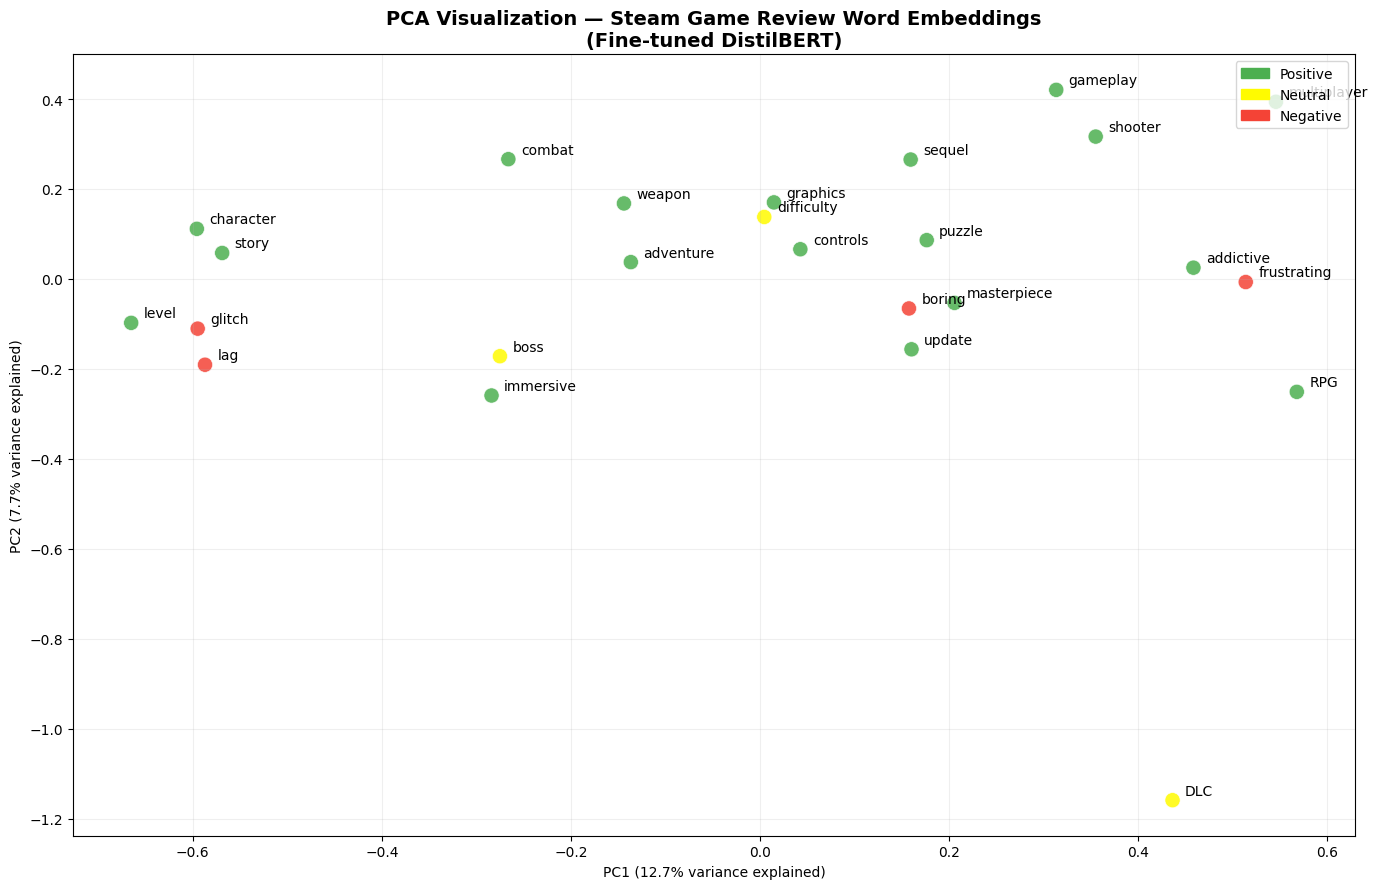

In [8]:
SENTIMENT_COLORS = {
    "positive": "#4CAF50",
    "neutral":  "#FFFB00",
    "negative": "#F44336",
}

WORD_SENTIMENTS = {
    "gameplay":    "positive",
    "graphics":    "positive",
    "story":       "positive",
    "multiplayer": "positive",
    "controls":    "positive",
    "difficulty":  "neutral",
    "combat":      "positive",
    "level":       "positive",
    "boss":        "neutral",
    "weapon":      "positive",
    "character":   "positive",
    "RPG":         "positive",
    "shooter":     "positive",
    "puzzle":      "positive",
    "adventure":   "positive",
    "lag":         "negative",
    "glitch":      "negative",
    "update":      "positive",
    "DLC":         "neutral",
    "sequel":      "positive",
    "immersive":   "positive",
    "boring":      "negative",
    "addictive":   "positive",
    "frustrating": "negative",
    "masterpiece": "positive",
}

def get_word_embedding(word, tokenizer, model):
    """Extract the embedding vector for a single word using DistilBERT."""
    inputs = tokenizer(word, return_tensors="pt")
    token_ids = inputs["input_ids"][0]

    tokens = tokenizer.convert_ids_to_tokens(token_ids)
    if len(tokens) > 3:  # [CLS], word, [SEP] = 3 is ideal
        print(f"Warning: '{word}' was split into subwords: {tokens[1:-1]}")

    with torch.no_grad():
        output = model.distilbert.embeddings.word_embeddings(token_ids.unsqueeze(0))

    return output[0][1].numpy()  # index 1 skips [CLS]

model.eval()
words   = list(WORD_SENTIMENTS.keys())
colors  = [SENTIMENT_COLORS[WORD_SENTIMENTS[w]] for w in words]
vectors = np.array([get_word_embedding(w, tokenizer, model) for w in words])

pca     = PCA(n_components=2)
reduced = pca.fit_transform(vectors)
var     = pca.explained_variance_ratio_ * 100

fig, ax = plt.subplots(figsize=(14, 9))
ax.scatter(reduced[:, 0], reduced[:, 1],
           c=colors, s=120, alpha=0.85,
           edgecolors="white", linewidths=0.5)

for i, word in enumerate(words):
    ax.annotate(word, (reduced[i, 0], reduced[i, 1]),
                textcoords="offset points", xytext=(9, 4), fontsize=10)

legend_handles = [
    mpatches.Patch(color=color, label=sentiment.capitalize())
    for sentiment, color in SENTIMENT_COLORS.items()
]
ax.legend(handles=legend_handles, loc="upper right")
ax.set_title("PCA Visualization — Steam Game Review Word Embeddings\n(Fine-tuned DistilBERT)",
             fontsize=14, fontweight="bold")
ax.set_xlabel(f"PC1 ({var[0]:.1f}% variance explained)")
ax.set_ylabel(f"PC2 ({var[1]:.1f}% variance explained)")
ax.grid(True, alpha=0.2)

fig.tight_layout()
fig.savefig("pca_steam_game_embeddings.png", dpi=150)
plt.show()